# 5293 Final Project
# Improving Faithfulness in RAG: Retrieval, Reranking, and Prompting Strategies

## Project Overview

Large language models can generate fluent answers, but they may still produce information that is not supported by evidence. Retrieval-Augmented Generation (RAG) is commonly used to reduce this problem by retrieving relevant passages and giving them to the model as context before answer generation. However, the final answer quality still depends on several design choices, including how passages are retrieved, whether they are reranked, and how the prompt instructs the model to use the evidence.

This project builds a simple RAG-based question answering system and compares different retrieval, reranking, and prompting strategies. The goal is not to train a new language model, but to evaluate how practical RAG design choices affect retrieval quality, answer quality, and faithfulness.

The main research questions are:

1. Does the retrieval method affect whether the system finds answer-supporting evidence?
2. Does cross-encoder reranking improve the quality of retrieved passages?
3. Do grounded prompting strategies make generated answers more faithful to the retrieved context?
4. Which combination of retrieval, reranking, and prompting works best in this simple RAG pipeline?

The project evaluates the system using both automatic and manual methods. Retrieval quality is measured using Recall@5. Answer quality is measured using Exact Match and token-level F1. Since these automatic metrics do not directly measure whether an answer is supported by evidence, we also include a small manual faithfulness review.

The final pipeline includes:

- BM25 sparse retrieval
- Dense retrieval using sentence embeddings
- Hybrid retrieval
- Cross-encoder reranking
- Standard, grounded, and evidence-based prompts
- Answer generation with a lightweight instruction-tuned model
- Automatic evaluation and manual faithfulness analysis
- A small interactive demo

## Setup

In [1]:
%%capture
!pip install -q datasets sentence-transformers rank-bm25 faiss-cpu evaluate rouge-score transformers accelerate

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

import re
from collections import Counter

## 1. Dataset Loading

We use a subset of the SQuAD validation set as the document-based question answering dataset. Each example contains a question, a reference context, and a ground-truth answer. For this project, the contexts are treated as the document collection for retrieval. The goal is to compare how different retrieval, reranking, and prompting strategies affect answer quality and faithfulness in a simple RAG pipeline.

In [10]:
raw_dataset = load_dataset("squad", split="validation")
dataset = raw_dataset.shuffle(seed=42).select(range(2000))

df = pd.DataFrame({
    "question": dataset["question"],
    "context": dataset["context"],
    "answer": [a["text"][0] if len(a["text"]) > 0 else "" for a in dataset["answers"]]
})

print("Number of QA pairs:", len(df))
print("Number of unique contexts:", df["context"].nunique())

df.head()

Number of QA pairs: 2000
Number of unique contexts: 1301


,question,context,answer
0,In what year did Massachusetts first require c...,Private schooling in the United States has bee...,1852
1,When were stromules discovered?,The chloroplast membranes sometimes protrude o...,1962
2,Which artist who had a major influence on the ...,Not only the work of British artists and craft...,Horace Walpole
3,"In 1890, who did the university decide to team...","In the 1890s, the University of Chicago, fearf...",several regional colleges and universities
4,Who got a touchdown making the score 10-7?,"After a punt from both teams, Carolina got on ...",Jonathan Stewart


In [11]:
N_RETRIEVAL_EVAL = 2000
N_RERANK_EVAL = 1000
N_GENERATION_EVAL = 200

In [12]:
print("Number of QA pairs:", len(df))
print("Number of unique contexts:", df["context"].nunique())

df[["question", "answer"]].sample(10, random_state=42)

Number of QA pairs: 2000
Number of unique contexts: 1301


,question,answer
1860,What is the weight of a bushel of coal in pounds?,94
353,What device is used to test the magnetic attra...,powerful magnet
1333,Whose relics reside in the Becket Casket?,St Thomas Becket
905,What do the owners of more capital end up having?,more wealth
1289,How many seats must a political party have to ...,five
1273,Who elects the members of the European Parliam...,citizens
938,How can function problems typically be restated?,decision problems
1731,What is the name of one type of computing meth...,distributed computing
65,"In Nepalese private schools, what is the prima...",English
1323,What are plants with plastid gene transformati...,transplastomic


## 2. Document Chunking

To build the retrieval corpus, we split each context passage into smaller text chunks. The document collection is built from a shuffled subset of 2,000 SQuAD validation examples. Chunking makes the setup closer to a standard RAG pipeline, where the retriever searches over shorter passages instead of full documents. We use a simple word-based chunking strategy with overlap so that information near chunk boundaries is less likely to be lost.

In [13]:
def chunk_text(text, chunk_size=120, overlap=30):
    words = text.split()
    chunks = []

    step = chunk_size - overlap
    for i in range(0, len(words), step):
        chunk = " ".join(words[i:i + chunk_size])
        if len(chunk.strip()) > 0:
            chunks.append(chunk)

    return chunks

In [6]:
documents = list(df["context"].drop_duplicates())

chunks = []

for doc_id, doc in enumerate(documents):
    doc_chunks = chunk_text(doc, chunk_size=120, overlap=30)

    for chunk_id, chunk in enumerate(doc_chunks):
        chunks.append({
            "doc_id": doc_id,
            "chunk_id": chunk_id,
            "text": chunk
        })

chunks_df = pd.DataFrame(chunks)

print("Number of original documents:", len(documents))
print("Number of chunks:", len(chunks_df))

chunks_df.head()

Number of original documents: 811
Number of chunks: 1549


,doc_id,chunk_id,text
0,0,0,Private schooling in the United States has bee...
1,1,0,The chloroplast membranes sometimes protrude o...
2,1,1,"However, there is a growing body of evidence t..."
3,2,0,Not only the work of British artists and craft...
4,2,1,"from their collections, these include: Horace ..."


## 3. BM25 Retrieval Baseline

The first retrieval method is BM25, a sparse keyword-based retrieval algorithm. BM25 is a strong and simple baseline because it ranks passages based on lexical overlap between the query and the document chunks. In this project, BM25 serves as the baseline retrieval method before comparing it with dense embedding-based retrieval and hybrid retrieval.

In [14]:
tokenized_corpus = [text.lower().split() for text in chunks_df["text"]]

bm25 = BM25Okapi(tokenized_corpus)

In [15]:
def retrieve_bm25(query, top_k=5):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = chunks_df.iloc[top_indices].copy()
    results["score"] = scores[top_indices]

    return results

In [16]:
sample_question = df["question"].iloc[0]
sample_answer = df["answer"].iloc[0]

print("Question:", sample_question)
print("Gold answer:", sample_answer)

bm25_results = retrieve_bm25(sample_question, top_k=5)
bm25_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score
870,457,0,Most early Greeks did not even consider 1 to b...,17.292574
130,68,0,"Some Huguenots settled in Bedfordshire, one of...",15.225546
1219,643,0,Closely related fields in theoretical computer...,13.940191
742,388,0,Education in Wales differs in certain respects...,13.898911
1282,677,0,"In regard to companies, the Court of Justice h...",13.889182


### Initial BM25 Check

The BM25 retriever returns the top-ranked chunks based on keyword overlap with the question. This initial check helps verify that the retrieval function works correctly and that the returned passages are reasonable candidates for answer generation.

In [17]:
for i, row in bm25_results.iterrows():
    print("=" * 80)
    print("Score:", row["score"])
    print(row["text"][:800])

Score: 17.292573803073573
Most early Greeks did not even consider 1 to be a number, so they could not consider it to be a prime. By the Middle Ages and Renaissance many mathematicians included 1 as the first prime number. In the mid-18th century Christian Goldbach listed 1 as the first prime in his famous correspondence with Leonhard Euler -- who did not agree. In the 19th century many mathematicians still considered the number 1 to be a prime. For example, Derrick Norman Lehmer's list of primes up to 10,006,721, reprinted as late as 1956, started with 1 as its first prime. Henri Lebesgue is said to be the last professional mathematician to call 1 prime. By the early 20th century, mathematicians began
Score: 15.225545820378619
Some Huguenots settled in Bedfordshire, one of the main centres of the British lace industry at the time. Although 19th century sources have asserted that some of these refugees were lacemakers and contributed to the East Midlands lace industry, this is contentio

## 4. Retrieval Evaluation

Before evaluating generated answers, we first evaluate whether the retriever can find passages that contain the gold answer. Since SQuAD provides a reference answer for each question, we use a simple Recall@5-style metric: a retrieval is counted as successful if the gold answer appears in at least one of the top five retrieved chunks.

This is not a perfect retrieval metric because it only checks exact answer string overlap, but it is useful as a simple and interpretable baseline for comparing retrieval methods. In this experiment, first-stage retrieval methods are evaluated on all 2,000 questions in the shuffled SQuAD subset.

In [18]:
def normalize_text(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = " ".join(s.split())
    return s


def answer_in_context(gold_answer, context):
    gold_answer = normalize_text(gold_answer)
    context = normalize_text(context)

    if len(gold_answer) == 0:
        return False

    return gold_answer in context


def retrieval_hit(gold_answer, retrieved_contexts):
    return int(any(answer_in_context(gold_answer, c) for c in retrieved_contexts))

In [19]:
def evaluate_bm25_retrieval(df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieve_bm25(question, top_k=top_k)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    recall_at_k = np.mean(hits)

    return recall_at_k

In [20]:
bm25_recall_at_5 = evaluate_bm25_retrieval(
    df,
    top_k=5,
    n_eval=N_RETRIEVAL_EVAL
)

print("BM25 Recall@5:", bm25_recall_at_5)

100%|██████████| 2000/2000 [00:09<00:00, 201.87it/s]

BM25 Recall@5: 0.599


### BM25 Retrieval Result

For the shuffled SQuAD subset, BM25 was evaluated on **2,000** questions and achieved a Recall@5 of **0.599**. This means that in approximately **59.9%** of evaluated questions, at least one of the top five retrieved chunks contained the gold answer string.

This result provides the baseline retrieval performance for the RAG system. Later experiments with dense retrieval, hybrid retrieval, and reranking will be compared against this BM25 baseline.

## 5. Dense Retrieval

The second retrieval method is dense retrieval using sentence embeddings. Unlike BM25, which relies on lexical overlap, dense retrieval maps both questions and document chunks into a continuous embedding space. This allows the retriever to find passages that are semantically related to the query even when they do not share the exact same words.

We use a pretrained SentenceTransformer model to encode all chunks from the shuffled 2,000-example SQuAD subset, and FAISS is used for efficient nearest-neighbor search.

In [21]:
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
chunk_embeddings = embed_model.encode(
    chunks_df["text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding shape:", chunk_embeddings.shape)

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Embedding shape: (1549, 384)


In [23]:
dimension = chunk_embeddings.shape[1]

dense_index = faiss.IndexFlatIP(dimension)
dense_index.add(chunk_embeddings)

print("Number of vectors in FAISS index:", dense_index.ntotal)

Number of vectors in FAISS index: 1549


In [24]:
def retrieve_dense(query, top_k=5):
    query_embedding = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = dense_index.search(query_embedding, top_k)

    results = chunks_df.iloc[indices[0]].copy()
    results["score"] = scores[0]

    return results

In [25]:
dense_results = retrieve_dense(sample_question, top_k=5)

print("Question:", sample_question)
print("Gold answer:", sample_answer)

dense_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score
0,0,0,Private schooling in the United States has bee...,0.632354
1097,575,1,of university. All schools had a common curric...,0.503367
925,489,0,During the mass high school education movement...,0.477054
1544,808,0,"In many parts of the United States, after the ...",0.437576
1127,592,1,"conversions, by liberalizing tuition fee polic...",0.415503


In [26]:
for i, row in dense_results.iterrows():
    print("=" * 80)
    print("Score:", row["score"])
    print(row["text"][:800])

Score: 0.6323538422584534
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).
Score: 0.5033669471740723
of university. All schools had a common curriculum.
Score: 0.4770544767379761
During the mass high school education movement from 1910–1940, there was an increase in skilled workers, which led to a decrease in the price of skilled labor. High school education during the period was designed to equip students with necessary skill sets to be able to perform at work. In fact, it differs from the present high

## 6. Dense Retrieval Evaluation

After building the dense retrieval index, we evaluate it using the same Recall@5 metric used for BM25. This allows a direct comparison between sparse keyword-based retrieval and dense semantic retrieval under the same dataset and evaluation setup.

Dense retrieval is evaluated on all 2,000 questions from the shuffled SQuAD subset.

In [27]:
def evaluate_dense_retrieval(df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieve_dense(question, top_k=top_k)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    recall_at_k = np.mean(hits)

    return recall_at_k

In [28]:
dense_recall_at_5 = evaluate_dense_retrieval(
    df,
    top_k=5,
    n_eval=N_RETRIEVAL_EVAL
)

print("Dense Recall@5:", dense_recall_at_5)

100%|██████████| 2000/2000 [00:15<00:00, 128.18it/s]

Dense Recall@5: 0.6575


In [29]:
retrieval_summary = pd.DataFrame({
    "Method": ["BM25", "Dense Retrieval"],
    "Recall@5": [bm25_recall_at_5, dense_recall_at_5]
})

retrieval_summary

,Method,Recall@5
0,BM25,0.5990
1,Dense Retrieval,0.6575


### BM25 vs. Dense Retrieval

BM25 achieved a Recall@5 of **0.5990**, while dense retrieval achieved a Recall@5 of **0.6575** on the first 100 validation examples.

This comparison shows whether semantic embedding-based retrieval improves over the sparse keyword baseline. BM25 can perform well when the question and answer context share similar wording, while dense retrieval may help when the relevant passage is semantically related but uses different words.

## 7. Hybrid Retrieval

The third retrieval method is hybrid retrieval, which combines sparse BM25 retrieval and dense embedding-based retrieval. BM25 is useful for exact keyword matching, while dense retrieval can capture semantic similarity. By combining both candidate sets, hybrid retrieval may improve robustness because it can retrieve passages that are relevant either lexically or semantically.

In this implementation, we retrieve a larger candidate pool from both BM25 and dense retrieval, merge the results, remove duplicate chunks, and rank candidates using a simple reciprocal-rank style score. This avoids giving priority only to whichever retriever appears first in the concatenated results.

In [30]:
def retrieve_hybrid(query, top_k=5, pool_k=10):
    bm25_results = retrieve_bm25(query, top_k=pool_k).copy()
    dense_results = retrieve_dense(query, top_k=pool_k).copy()

    bm25_results["source"] = "bm25"
    dense_results["source"] = "dense"

    bm25_results["rank"] = np.arange(1, len(bm25_results) + 1)
    dense_results["rank"] = np.arange(1, len(dense_results) + 1)

    bm25_results["hybrid_score"] = 1 / bm25_results["rank"]
    dense_results["hybrid_score"] = 1 / dense_results["rank"]

    combined = pd.concat([bm25_results, dense_results], axis=0)

    combined = (
        combined
        .groupby(["doc_id", "chunk_id"], as_index=False)
        .agg({
            "text": "first",
            "score": "max",
            "source": lambda x: "+".join(sorted(set(x))),
            "rank": "min",
            "hybrid_score": "sum"
        })
    )

    combined = combined.sort_values("hybrid_score", ascending=False)

    return combined.head(top_k)

In [31]:
hybrid_results = retrieve_hybrid(sample_question, top_k=5, pool_k=10)

print("Question:", sample_question)
print("Gold answer:", sample_answer)

hybrid_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score,source,rank,hybrid_score
0,0,0,Private schooling in the United States has bee...,0.632354,dense,1,1.000000
9,457,0,Most early Greeks did not even consider 1 to b...,17.292574,bm25,1,1.000000
12,575,1,of university. All schools had a common curric...,0.503367,dense,2,0.500000
3,68,0,"Some Huguenots settled in Bedfordshire, one of...",15.225546,bm25,2,0.500000
15,643,0,Closely related fields in theoretical computer...,13.940191,bm25,3,0.333333


In [32]:
for i, row in hybrid_results.iterrows():
    print("=" * 80)
    print("Source:", row["source"])
    print("Hybrid score:", row["hybrid_score"])
    print(row["text"][:800])

Source: dense
Hybrid score: 1.0
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).
Source: bm25
Hybrid score: 1.0
Most early Greeks did not even consider 1 to be a number, so they could not consider it to be a prime. By the Middle Ages and Renaissance many mathematicians included 1 as the first prime number. In the mid-18th century Christian Goldbach listed 1 as the first prime in his famous correspondence with Leonhard Euler -- who did not agree. In the 19th century many mathematicians still considered t

## 8. Hybrid Retrieval Evaluation

We evaluate hybrid retrieval using the same Recall@5 metric. Since hybrid retrieval combines BM25 and dense retrieval candidates, the goal is to test whether combining lexical and semantic search improves the chance of retrieving a passage that contains the gold answer.

Hybrid retrieval is evaluated on all 2,000 questions from the shuffled SQuAD subset.

In [33]:
def evaluate_hybrid_retrieval(df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieve_hybrid(question, top_k=top_k, pool_k=10)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    recall_at_k = np.mean(hits)

    return recall_at_k

In [34]:
hybrid_recall_at_5 = evaluate_hybrid_retrieval(
    df,
    top_k=5,
    n_eval=N_RETRIEVAL_EVAL
)

print("Hybrid Recall@5:", hybrid_recall_at_5)

100%|██████████| 2000/2000 [00:39<00:00, 50.76it/s]

Hybrid Recall@5: 0.6885


In [35]:
retrieval_summary = pd.DataFrame({
    "Method": ["BM25", "Dense Retrieval", "Hybrid Retrieval"],
    "Recall@5": [bm25_recall_at_5, dense_recall_at_5, hybrid_recall_at_5]
})

retrieval_summary

,Method,Recall@5
0,BM25,0.5990
1,Dense Retrieval,0.6575
2,Hybrid Retrieval,0.6885


### Retrieval Method Comparison

The first-stage retrieval results show that BM25 achieved a Recall@5 of **0.5990**, dense retrieval achieved a Recall@5 of **0.6575**, and hybrid retrieval achieved a Recall@5 of **0.6885** on all **2,000** questions from the shuffled SQuAD subset.

These results suggest that retrieval method choice has a clear effect on whether the RAG system can access answer-supporting evidence. Since answer generation depends heavily on the retrieved context, stronger retrieval performance is expected to improve downstream answer quality and faithfulness.

## 9. Reranking

After retrieval, we add a reranking step to improve the ordering of retrieved passages. The first-stage retriever returns a candidate pool, but the top-ranked passages may not always be the most relevant ones. A cross-encoder reranker scores each question-passage pair jointly, which usually gives a more accurate relevance score than using BM25 scores or embedding similarity alone.

In this project, reranking is applied after first-stage retrieval. We first retrieve a larger candidate pool, then use the reranker to select the final top five passages. Since reranking requires scoring each query-passage pair with a transformer model, it is more computationally expensive than first-stage retrieval.

In [36]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
def rerank_results(query, retrieved_df, top_k=5):
    if len(retrieved_df) == 0:
        return retrieved_df

    pairs = [(query, text) for text in retrieved_df["text"].tolist()]
    scores = reranker.predict(pairs)

    reranked = retrieved_df.copy()
    reranked["rerank_score"] = scores
    reranked = reranked.sort_values("rerank_score", ascending=False)

    return reranked.head(top_k)

## 10. Reranked Retrieval Evaluation

We evaluate whether reranking improves retrieval quality by applying the cross-encoder reranker to candidate pools from BM25, dense retrieval, and hybrid retrieval. For each method, the retriever first returns a larger candidate set, and the reranker then selects the final top five passages.

Because reranking is more computationally expensive than first-stage retrieval, reranked retrieval is evaluated on a subset of the questions rather than the full 2,000-question evaluation set.

In [39]:
def retrieve_bm25_reranked(query, top_k=5, pool_k=20):
    candidates = retrieve_bm25(query, top_k=pool_k).copy()
    candidates["source"] = "bm25"
    return rerank_results(query, candidates, top_k=top_k)


def retrieve_dense_reranked(query, top_k=5, pool_k=20):
    candidates = retrieve_dense(query, top_k=pool_k).copy()
    candidates["source"] = "dense"
    return rerank_results(query, candidates, top_k=top_k)


def retrieve_hybrid_reranked(query, top_k=5, pool_k=20):
    bm25_candidates = retrieve_bm25(query, top_k=pool_k).copy()
    dense_candidates = retrieve_dense(query, top_k=pool_k).copy()

    bm25_candidates["source"] = "bm25"
    dense_candidates["source"] = "dense"

    bm25_candidates["rank"] = np.arange(1, len(bm25_candidates) + 1)
    dense_candidates["rank"] = np.arange(1, len(dense_candidates) + 1)

    bm25_candidates["hybrid_score"] = 1 / bm25_candidates["rank"]
    dense_candidates["hybrid_score"] = 1 / dense_candidates["rank"]

    candidates = pd.concat([bm25_candidates, dense_candidates], axis=0)

    candidates = (
        candidates
        .groupby(["doc_id", "chunk_id"], as_index=False)
        .agg({
            "text": "first",
            "score": "max",
            "source": lambda x: "+".join(sorted(set(x))),
            "rank": "min",
            "hybrid_score": "sum"
        })
    )

    candidates = candidates.sort_values("hybrid_score", ascending=False)

    return rerank_results(query, candidates, top_k=top_k)

In [40]:
hybrid_reranked_results = retrieve_hybrid_reranked(sample_question, top_k=5, pool_k=20)

print("Question:", sample_question)
print("Gold answer:", sample_answer)

hybrid_reranked_results

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852


,doc_id,chunk_id,text,score,source,rank,hybrid_score,rerank_score
0,0,0,Private schooling in the United States has bee...,12.727243,bm25+dense,1,1.071429,3.817114
37,762,0,Harvard was formed in 1636 by vote of the Grea...,13.312279,bm25,9,0.111111,-4.093204
27,575,0,Kenya's first system of education was introduc...,0.376215,dense,8,0.125000,-4.709186
24,489,0,During the mass high school education movement...,0.477054,dense,3,0.333333,-4.785449
1,3,0,"In the 1890s, the University of Chicago, fearf...",0.374156,dense,9,0.111111,-6.878719


In [41]:
for i, row in hybrid_reranked_results.iterrows():
    print("=" * 80)
    print("Source:", row.get("source", "unknown"))
    print("Rerank score:", row.get("rerank_score", None))
    print("Hybrid score:", row.get("hybrid_score", None))
    print(row["text"][:800])

Source: bm25+dense
Rerank score: 3.8171141147613525
Hybrid score: 1.0714285714285714
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).
Source: bm25
Rerank score: -4.093203544616699
Hybrid score: 0.1111111111111111
Harvard was formed in 1636 by vote of the Great and General Court of the Massachusetts Bay Colony. It was initially called "New College" or "the college at New Towne". In 1638, the college became home for North America's first known printing press, carried by the ship John of London. In 1639, t

## 11. Evaluate Reranked Retrieval

In [42]:
def evaluate_retrieval_function(retrieval_fn, df, top_k=5, n_eval=100):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    hits = []

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
        question = row["question"]
        gold_answer = row["answer"]

        retrieved = retrieval_fn(question, top_k=top_k)
        retrieved_contexts = retrieved["text"].tolist()

        hit = retrieval_hit(gold_answer, retrieved_contexts)
        hits.append(hit)

    return np.mean(hits)

In [43]:
bm25_rerank_recall_at_5 = evaluate_retrieval_function(
    retrieve_bm25_reranked,
    df,
    top_k=5,
    n_eval=N_RERANK_EVAL
)

dense_rerank_recall_at_5 = evaluate_retrieval_function(
    retrieve_dense_reranked,
    df,
    top_k=5,
    n_eval=N_RERANK_EVAL
)

hybrid_rerank_recall_at_5 = evaluate_retrieval_function(
    retrieve_hybrid_reranked,
    df,
    top_k=5,
    n_eval=N_RERANK_EVAL
)

print("BM25 + Rerank Recall@5:", bm25_rerank_recall_at_5)
print("Dense + Rerank Recall@5:", dense_rerank_recall_at_5)
print("Hybrid + Rerank Recall@5:", hybrid_rerank_recall_at_5)

100%|██████████| 1000/1000 [00:52<00:00, 19.03it/s]

BM25 + Rerank Recall@5: 0.899
Dense + Rerank Recall@5: 0.953
Hybrid + Rerank Recall@5: 0.979


In [44]:
retrieval_summary = pd.DataFrame({
    "Method": [
        "BM25",
        "Dense Retrieval",
        "Hybrid Retrieval",
        "BM25 + Rerank",
        "Dense + Rerank",
        "Hybrid + Rerank"
    ],
    "Recall@5": [
        bm25_recall_at_5,
        dense_recall_at_5,
        hybrid_recall_at_5,
        bm25_rerank_recall_at_5,
        dense_rerank_recall_at_5,
        hybrid_rerank_recall_at_5
    ]
})

retrieval_summary

,Method,Recall@5
0,BM25,0.5990
1,Dense Retrieval,0.6575
2,Hybrid Retrieval,0.6885
3,BM25 + Rerank,0.8990
4,Dense + Rerank,0.9530
5,Hybrid + Rerank,0.9790


### Reranking Result

After adding the cross-encoder reranker, BM25 + reranking achieved a Recall@5 of **0.8990**, dense retrieval + reranking achieved a Recall@5 of **0.9530**, and hybrid retrieval + reranking achieved a Recall@5 of **0.9790** on **1,000** evaluated questions.

Compared with the first-stage retrieval results, reranking substantially improved retrieval performance. BM25 increased from **0.5990** to **0.8990**, dense retrieval increased from **0.6575** to **0.9530**, and hybrid retrieval increased from **0.6885** to **0.9790**. This suggests that the correct evidence was often present in the larger candidate pool but was not ranked highly enough by the first-stage retriever.

Overall, **Hybrid + Rerank** achieved the strongest retrieval performance, with a Recall@5 of **0.9790**. This supports the idea that combining sparse and dense retrieval can provide a stronger candidate pool, while cross-encoder reranking improves the final ordering of retrieved passages.

## 12. Prompting Strategies

After retrieving relevant passages, the next step is answer generation. Since the project studies faithfulness in RAG, we compare different prompting strategies to see whether stricter instructions help the model stay closer to the retrieved evidence.

We use three prompt types:

1. **Standard prompt**: asks the model to answer using the retrieved context.
2. **Grounded prompt**: explicitly tells the model to answer only from the provided context and say "Not enough information" if the answer is unsupported.
3. **Evidence prompt**: asks the model to answer and identify which passage supports the answer.

These prompts allow us to evaluate whether prompt design affects answer quality and faithfulness after retrieval.

In [45]:
def build_standard_prompt(question, contexts):
    context_text = "\n\n".join(contexts)

    return f"""
Answer the question using the following context.

Context:
{context_text}

Question:
{question}

Answer:
"""


def build_grounded_prompt(question, contexts):
    context_text = "\n\n".join(contexts)

    return f"""
You must answer the question only using the provided context.
If the answer is not supported by the context, say "Not enough information."

Context:
{context_text}

Question:
{question}

Grounded answer:
"""


def build_evidence_prompt(question, contexts):
    context_text = "\n\n".join(
        [f"[Passage {i+1}] {context}" for i, context in enumerate(contexts)]
    )

    return f"""
Answer the question using only the passages below.
After the answer, briefly mention which passage supports it.

Passages:
{context_text}

Question:
{question}

Answer:
Evidence:
"""

In [46]:
test_contexts = hybrid_reranked_results["text"].tolist()

print(build_grounded_prompt(sample_question, test_contexts)[:2000])


You must answer the question only using the provided context.
If the answer is not supported by the context, say "Not enough information."

Context:
Private schooling in the United States has been debated by educators, lawmakers and parents, since the beginnings of compulsory education in Massachusetts in 1852. The Supreme Court precedent appears to favor educational choice, so long as states may set standards for educational accomplishment. Some of the most relevant Supreme Court case law on this is as follows: Runyon v. McCrary, 427 U.S. 160 (1976); Wisconsin v. Yoder, 406 U.S. 205 (1972); Pierce v. Society of Sisters, 268 U.S. 510 (1925); Meyer v. Nebraska, 262 U.S. 390 (1923).

Harvard was formed in 1636 by vote of the Great and General Court of the Massachusetts Bay Colony. It was initially called "New College" or "the college at New Towne". In 1638, the college became home for North America's first known printing press, carried by the ship John of London. In 1639, the college wa

## 13. Answer Generation Model

For answer generation, we use `google/flan-t5-base`, a lightweight instruction-tuned sequence-to-sequence model. This model is small enough to run efficiently in Google Colab while still supporting instruction-style prompting.

Since this project focuses on comparing RAG design choices rather than training a new language model, using a pretrained generator keeps the scope manageable. In the later generation experiments, we evaluate answer quality on a subset of 200 questions because answer generation is more computationally expensive than retrieval.

In [47]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

generator_model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(generator_model_name)
generation_model = AutoModelForSeq2SeqLM.from_pretrained(generator_model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
generation_model = generation_model.to(device)

print("Using device:", device)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Using device: cuda


In [48]:
def generate_answer(prompt, max_new_tokens=128):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = generation_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

In [49]:
sample_contexts = retrieve_hybrid_reranked(sample_question, top_k=5, pool_k=20)["text"].tolist()
sample_prompt = build_grounded_prompt(sample_question, sample_contexts)

sample_generated_answer = generate_answer(sample_prompt)

print("Question:", sample_question)
print("Gold answer:", sample_answer)
print("Generated answer:", sample_generated_answer)

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852
Generated answer: Not enough information.


## 14. Full RAG Pipeline

We now combine retrieval, optional reranking, prompting, and answer generation into a single RAG function. This function allows us to run controlled experiments across different retrieval methods, reranking settings, and prompt types.

The full pipeline follows this structure:

1. Retrieve candidate passages using BM25, dense retrieval, or hybrid retrieval.
2. Optionally apply cross-encoder reranking.
3. Build a prompt using the selected prompting strategy.
4. Generate an answer using the pretrained generation model.
5. Return the generated answer and retrieved evidence for evaluation.

In [50]:
def get_retrieved_contexts(question, retrieval_method="dense", use_rerank=True, top_k=5, pool_k=20):
    if retrieval_method == "bm25":
        if use_rerank:
            retrieved = retrieve_bm25_reranked(question, top_k=top_k, pool_k=pool_k)
        else:
            retrieved = retrieve_bm25(question, top_k=top_k)

    elif retrieval_method == "dense":
        if use_rerank:
            retrieved = retrieve_dense_reranked(question, top_k=top_k, pool_k=pool_k)
        else:
            retrieved = retrieve_dense(question, top_k=top_k)

    elif retrieval_method == "hybrid":
        if use_rerank:
            retrieved = retrieve_hybrid_reranked(question, top_k=top_k, pool_k=pool_k)
        else:
            retrieved = retrieve_hybrid(question, top_k=top_k, pool_k=pool_k)

    else:
        raise ValueError("Invalid retrieval method.")

    return retrieved


def build_prompt(question, contexts, prompt_type="grounded"):
    if prompt_type == "standard":
        return build_standard_prompt(question, contexts)
    elif prompt_type == "grounded":
        return build_grounded_prompt(question, contexts)
    elif prompt_type == "evidence":
        return build_evidence_prompt(question, contexts)
    else:
        raise ValueError("Invalid prompt type.")


def run_rag(question, retrieval_method="dense", use_rerank=True, prompt_type="grounded", top_k=5, pool_k=20):
    retrieved = get_retrieved_contexts(
        question=question,
        retrieval_method=retrieval_method,
        use_rerank=use_rerank,
        top_k=top_k,
        pool_k=pool_k
    )

    contexts = retrieved["text"].tolist()
    prompt = build_prompt(question, contexts, prompt_type=prompt_type)
    generated_answer = generate_answer(prompt)

    return {
        "question": question,
        "generated_answer": generated_answer,
        "retrieved_contexts": contexts,
        "retrieved_df": retrieved,
        "prompt": prompt
    }

In [51]:
test_output = run_rag(
    question=sample_question,
    retrieval_method="hybrid",
    use_rerank=True,
    prompt_type="grounded",
    top_k=5,
    pool_k=20
)

print("Question:", test_output["question"])
print("Gold answer:", sample_answer)
print("Generated answer:", test_output["generated_answer"])

Question: In what year did Massachusetts first require children to be educated in schools?
Gold answer: 1852
Generated answer: Not enough information.


## 15. Automatic Answer Evaluation

After building the full RAG pipeline, we evaluate generated answers using Exact Match and token-level F1. Exact Match measures whether the generated answer exactly matches the gold answer after normalization. F1 is more flexible because it measures word overlap between the generated answer and the gold answer.

These metrics are not perfect measures of faithfulness, but they provide a useful automatic measure of answer quality and allow us to compare different RAG configurations. Since answer generation is computationally more expensive than retrieval, answer quality is evaluated on a subset of 200 questions.

In [52]:
def exact_match_score(prediction, gold_answer):
    return int(normalize_text(prediction) == normalize_text(gold_answer))


def token_f1_score(prediction, gold_answer):
    pred_tokens = normalize_text(prediction).split()
    gold_tokens = normalize_text(gold_answer).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

## 16. RAG Experiment Setup

We compare several RAG configurations that vary by retrieval method, reranking, and prompt type. The selected configurations are designed to answer the main project questions: whether retrieval method matters, whether reranking improves performance, and whether prompting strategy affects answer quality.

Answer generation is evaluated on 200 questions across seven configurations, producing 1,400 generated answers in total.

In [53]:
experiment_configs = [
    {
        "config_name": "BM25 + Standard",
        "retrieval_method": "bm25",
        "use_rerank": False,
        "prompt_type": "standard"
    },
    {
        "config_name": "BM25 + Grounded",
        "retrieval_method": "bm25",
        "use_rerank": False,
        "prompt_type": "grounded"
    },
    {
        "config_name": "BM25 + Rerank + Grounded",
        "retrieval_method": "bm25",
        "use_rerank": True,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Dense + Grounded",
        "retrieval_method": "dense",
        "use_rerank": False,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Dense + Rerank + Grounded",
        "retrieval_method": "dense",
        "use_rerank": True,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Hybrid + Rerank + Grounded",
        "retrieval_method": "hybrid",
        "use_rerank": True,
        "prompt_type": "grounded"
    },
    {
        "config_name": "Hybrid + Rerank + Evidence",
        "retrieval_method": "hybrid",
        "use_rerank": True,
        "prompt_type": "evidence"
    }
]

In [54]:
def run_experiments(df, configs, n_eval=50, top_k=5, pool_k=20):
    eval_df = df.iloc[:min(n_eval, len(df))].copy()
    all_results = []

    for config in configs:
        print("Running config:", config["config_name"])

        for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
            question = row["question"]
            gold_answer = row["answer"]

            rag_output = run_rag(
                question=question,
                retrieval_method=config["retrieval_method"],
                use_rerank=config["use_rerank"],
                prompt_type=config["prompt_type"],
                top_k=top_k,
                pool_k=pool_k
            )

            generated_answer = rag_output["generated_answer"]
            retrieved_contexts = rag_output["retrieved_contexts"]

            all_results.append({
                "config_name": config["config_name"],
                "retrieval_method": config["retrieval_method"],
                "use_rerank": config["use_rerank"],
                "prompt_type": config["prompt_type"],
                "question": question,
                "gold_answer": gold_answer,
                "generated_answer": generated_answer,
                "top_context": retrieved_contexts[0] if len(retrieved_contexts) > 0 else "",
                "em": exact_match_score(generated_answer, gold_answer),
                "f1": token_f1_score(generated_answer, gold_answer)
            })

    return pd.DataFrame(all_results)

In [55]:
rag_results_df = run_experiments(
    df=df,
    configs=experiment_configs,
    n_eval=N_GENERATION_EVAL,
    top_k=5,
    pool_k=20
)

rag_results_df.head()

Running config: BM25 + Standard


100%|██████████| 200/200 [00:49<00:00,  4.04it/s]


Running config: BM25 + Grounded


100%|██████████| 200/200 [00:36<00:00,  5.41it/s]


Running config: BM25 + Rerank + Grounded


...

Running config: Hybrid + Rerank + Grounded


100%|██████████| 200/200 [00:42<00:00,  4.68it/s]


Running config: Hybrid + Rerank + Evidence


100%|██████████| 200/200 [00:41<00:00,  4.84it/s]


,config_name,retrieval_method,use_rerank,prompt_type,question,gold_answer,generated_answer,top_context,em,f1
0,BM25 + Standard,bm25,False,standard,In what year did Massachusetts first require c...,1852,computational complexity theory,Most early Greeks did not even consider 1 to b...,0,0.0
1,BM25 + Standard,bm25,False,standard,When were stromules discovered?,1962,1962,The chloroplast membranes sometimes protrude o...,1,1.0
2,BM25 + Standard,bm25,False,standard,Which artist who had a major influence on the ...,Horace Walpole,Warsaw.,Not only the work of British artists and craft...,0,0.0
3,BM25 + Standard,bm25,False,standard,"In 1890, who did the university decide to team...",several regional colleges and universities,Kurt Coleman,"in just 9 starts. Behind them, two of the Pant...",0,0.0
4,BM25 + Standard,bm25,False,standard,Who got a touchdown making the score 10-7?,Jonathan Stewart,"Ward, it took a long bounce backwards and was ...","After a punt from both teams, Carolina got on ...",0,0.0


## 17. Answer Quality Results

The experiment results are summarized using average Exact Match and F1 scores for each RAG configuration. This table shows how retrieval method, reranking, and prompting affect downstream answer generation quality.

The answer generation experiment uses 200 questions and seven RAG configurations, resulting in 1,400 generated answers.

In [56]:
answer_quality_summary = (
    rag_results_df
    .groupby("config_name")[["em", "f1"]]
    .mean()
    .reset_index()
    .sort_values("f1", ascending=False)
)

answer_quality_summary

,config_name,em,f1
3,Dense + Grounded,0.130,0.167159
4,Dense + Rerank + Grounded,0.100,0.119773
6,Hybrid + Rerank + Grounded,0.080,0.096869
2,BM25 + Standard,0.065,0.092813
5,Hybrid + Rerank + Evidence,0.075,0.091567
0,BM25 + Grounded,0.045,0.060410
1,BM25 + Rerank + Grounded,0.015,0.023357


In [57]:
rag_results_df.to_csv("rag_generation_results.csv", index=False)
answer_quality_summary.to_csv("answer_quality_summary.csv", index=False)

### Answer Quality Result

The automatic answer evaluation results show that answer generation performance was lower than retrieval performance. The best configuration was **Dense + Grounded**, with an Exact Match score of **0.130** and an F1 score of **0.167**.

Dense retrieval-based configurations performed best overall. **Dense + Rerank + Grounded** achieved the second-highest result, with an Exact Match score of **0.100** and an F1 score of **0.120**. **Hybrid + Rerank + Grounded** achieved an Exact Match score of **0.080** and an F1 score of **0.097**. BM25-based configurations performed worse, especially **BM25 + Rerank + Grounded**, which had the lowest F1 score.

Compared with the retrieval results, the answer quality scores suggest that retrieving relevant evidence is not sufficient by itself. Even when the retriever finds answer-supporting passages, the generation model may still fail to extract the correct short answer. This is especially important for SQuAD-style evaluation, where the reference answer is usually a short span and Exact Match is strict.

The evidence-based prompt should also be interpreted carefully. Since it asks the model to output both an answer and supporting evidence, the generated text may contain extra information beyond the short gold answer. This can lower EM and F1 even when the output is partially supported by the retrieved context.

Overall, the automatic evaluation suggests that the main bottleneck is answer generation rather than retrieval. Dense retrieval helped answer quality more than BM25, but reranking did not consistently improve generation results, even though it greatly improved retrieval Recall@5.

## 18. Visualization of Results

To make the comparison easier to interpret, we visualize both retrieval performance and answer generation performance. The retrieval plot compares Recall@5 across first-stage and reranked retrieval settings, while the answer quality plot compares Exact Match and F1 across full RAG configurations.

These visualizations help separate two parts of the RAG pipeline: whether the system retrieves answer-supporting evidence, and whether the generator produces the correct final answer.

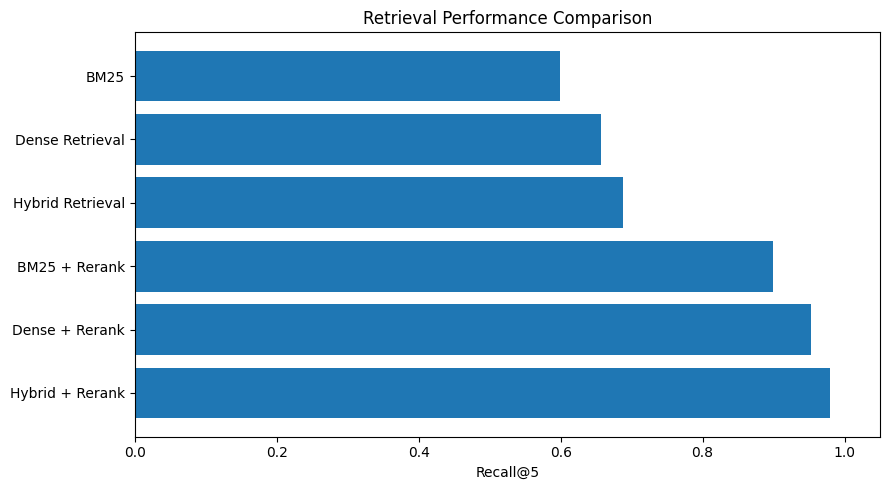

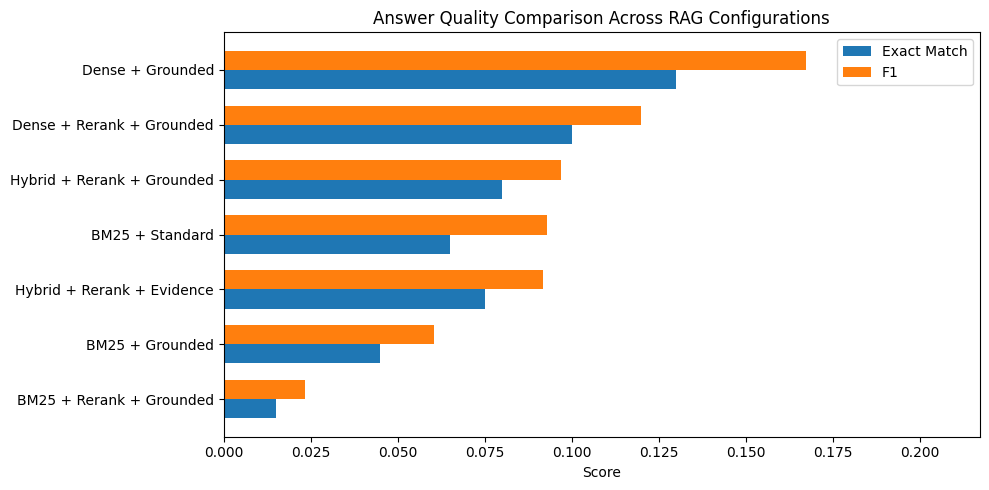

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(retrieval_summary["Method"], retrieval_summary["Recall@5"])
plt.xlabel("Recall@5")
plt.title("Retrieval Performance Comparison")
plt.xlim(0, 1.05)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("retrieval_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

plot_df = answer_quality_summary.copy()
plot_df = plot_df.sort_values("f1", ascending=True)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.barh(x - width/2, plot_df["em"], height=width, label="Exact Match")
plt.barh(x + width/2, plot_df["f1"], height=width, label="F1")
plt.yticks(x, plot_df["config_name"])
plt.xlabel("Score")
plt.title("Answer Quality Comparison Across RAG Configurations")
plt.xlim(0, max(plot_df["f1"].max(), plot_df["em"].max()) + 0.05)
plt.legend()
plt.tight_layout()
plt.savefig("answer_quality_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization Summary

The retrieval visualization shows that reranking substantially improved retrieval performance across all retrieval methods. Among the first-stage retrievers, hybrid retrieval performed best with a Recall@5 of **0.6885**, followed by dense retrieval with **0.6575** and BM25 with **0.5990**. After reranking, all retrieval methods improved substantially. The strongest retrieval setting was **Hybrid + Rerank**, which achieved a Recall@5 of **0.9790**.

The answer quality visualization shows a different pattern. Although reranking greatly improved retrieval Recall@5, it did not consistently improve answer generation performance. The best answer generation configuration was **Dense + Grounded**, with an Exact Match score of **0.130** and an F1 score of **0.167**. This suggests that the main bottleneck shifted from retrieving relevant evidence to generating concise and correct answers from that evidence.

Together, the visualizations show that retrieval quality and answer quality should be analyzed separately. Strong retrieval increases access to supporting evidence, but the final answer still depends on the generation model and prompt behavior.

## 19. Manual Faithfulness Evaluation

Automatic metrics such as Exact Match and F1 measure answer overlap with the reference answer, but they do not directly measure whether the generated answer is supported by the retrieved context. Since the main goal of this project is to study faithfulness in RAG, we also conduct a small manual evaluation.

For this evaluation, we sample generated answers from different RAG configurations and manually check whether each answer is supported by the retrieved top context. Each example is labeled using the following scale:

- **1.0**: fully supported by the retrieved context
- **0.5**: partially supported, incomplete, vague, or overly conservative but not hallucinated
- **0.0**: unsupported, incorrect, or hallucinated

This manual review provides a more direct measure of faithfulness than EM or F1 alone.

In [60]:
manual_review_df = (
    rag_results_df
    .groupby("config_name", group_keys=False)
    .apply(lambda x: x.sample(min(4, len(x)), random_state=42))
    .reset_index(drop=True)
)

manual_review_df = manual_review_df[
    [
        "config_name",
        "question",
        "gold_answer",
        "generated_answer",
        "top_context",
        "em",
        "f1"
    ]
].copy()

manual_review_df["faithfulness_label"] = ""
manual_review_df["error_type"] = ""

manual_review_df.to_csv("manual_faithfulness_review_unlabeled.csv", index=False)

manual_review_df

/tmp/ipykernel_43960/2206129528.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(4, len(x)), random_state=42))


,config_name,question,gold_answer,generated_answer,top_context,em,f1,faithfulness_label,error_type
0,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0,0.000000,,
1,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,Paramount Television prior to 1986 (as Miller-...,0,0.000000,,
2,BM25 + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0,0.000000,,
3,BM25 + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0,0.000000,,
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0,0.000000,,
5,BM25 + Rerank + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Yuan dynasty,Bolshevik leaders had effectively reestablishe...,0,0.000000,,
6,BM25 + Rerank + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0,0.000000,,
7,BM25 + Rerank + Grounded,What service is a VideoGuard UK equipped recei...,Sky,"BSkyB's analogue service on 27 September 2001,...",Provided is a universal Ku band LNB (9.75/10.6...,0,0.105263,,
8,BM25 + Standard,What does co-teaching get the students to focu...,learning,The Clouded Yellow,Co-teaching has also become a new trend amongs...,0,0.000000,,
9,BM25 + Standard,Who had established the Russian empire to its ...,Bolshevik leaders,Subutai had a large wooden platform constructe...,Paramount Television prior to 1986 (as Miller-...,0,0.000000,,


### Manual Labeling Guide

After exporting the sampled results, each example is manually reviewed by comparing the generated answer with the retrieved top context.

The `faithfulness_label` column is filled using:

- `1.0` if the generated answer is clearly supported by the retrieved context.
- `0.5` if the generated answer is partially supported but incomplete, vague, or mixed with unsupported information.
- `0.0` if the generated answer is not supported by the retrieved context or is clearly incorrect.

The `error_type` column is filled using one of the following categories:

- `correct_supported`
- `partially_supported`
- `unsupported_claim`
- `wrong_answer`
- `retrieval_failure`
- `over_refusal`
- `format_mismatch`

In [61]:
manual_labeled_df = pd.read_csv("manual_faithfulness_review_labeled.csv")

manual_labeled_df["faithfulness_label"] = manual_labeled_df["faithfulness_label"].astype(float)

manual_labeled_df.head()

,config_name,question,gold_answer,generated_answer,top_context,em,f1,faithfulness_label,error_type
0,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0,0.0,0.5,over_refusal
1,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,Paramount Television prior to 1986 (as Miller-...,0,0.0,0.5,retrieval_failure
2,BM25 + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0,0.0,0.5,over_refusal
3,BM25 + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0,0.0,0.5,over_refusal
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0,0.0,0.5,partially_supported


In [62]:
faithfulness_summary = (
    manual_labeled_df
    .groupby("config_name")["faithfulness_label"]
    .mean()
    .reset_index()
    .sort_values("faithfulness_label", ascending=False)
)

faithfulness_summary

,config_name,faithfulness_label
0,BM25 + Grounded,0.500
4,Dense + Rerank + Grounded,0.500
3,Dense + Grounded,0.500
6,Hybrid + Rerank + Grounded,0.375
1,BM25 + Rerank + Grounded,0.250
5,Hybrid + Rerank + Evidence,0.125
2,BM25 + Standard,0.000


In [63]:
error_type_summary = (
    manual_labeled_df["error_type"]
    .value_counts()
    .reset_index()
)

error_type_summary.columns = ["error_type", "count"]

error_type_summary

,error_type,count
0,over_refusal,14
1,wrong_answer,7
2,partially_supported,3
3,format_mismatch,3
4,retrieval_failure,1


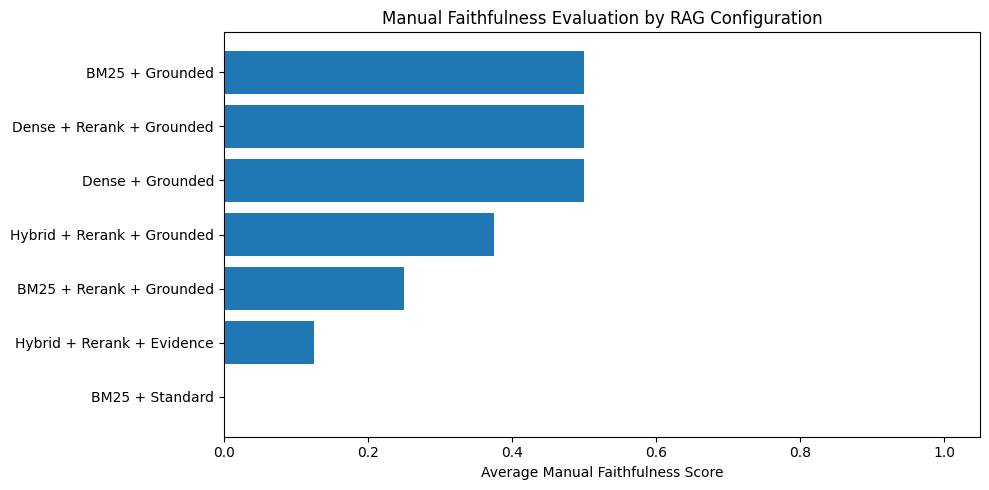

In [64]:
plt.figure(figsize=(10, 5))
plot_df = faithfulness_summary.sort_values("faithfulness_label", ascending=True)

plt.barh(plot_df["config_name"], plot_df["faithfulness_label"])
plt.xlabel("Average Manual Faithfulness Score")
plt.title("Manual Faithfulness Evaluation by RAG Configuration")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig("manual_faithfulness_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Manual Faithfulness Result

The manual faithfulness review provides a more direct evaluation of whether generated answers are supported by the retrieved context. Unlike Exact Match and F1, this evaluation focuses on evidence support rather than exact overlap with the reference answer.

Based on the manually labeled sample, the highest average faithfulness scores were achieved by **BM25 + Grounded**, **Dense + Grounded**, and **Dense + Rerank + Grounded**, each with an average faithfulness score of **0.50**. The lowest-scoring configuration was **BM25 + Standard**, with an average faithfulness score of **0.00**.

The most common error type was **over-refusal**, which occurred 14 times in the manually reviewed sample. In these cases, the retrieved context often contained enough evidence to answer the question, but the grounded prompt caused the model to respond with “Not enough information.” This suggests that grounded prompting reduced unsupported generation but also made the small generator overly conservative.

The second most common issue was **wrong answer generation**, which occurred 7 times. These cases show that even when retrieved evidence was relevant, the model sometimes selected the wrong entity or produced an unrelated answer. The evidence-based prompt also caused several **format mismatch** errors, where the model returned passage numbers or malformed outputs instead of a direct answer.

Overall, the manual evaluation helps explain why retrieval and answer-generation metrics can differ. Reranking improved access to relevant evidence, but the generation model still struggled to extract concise answers from that evidence. Therefore, manual faithfulness evaluation is an important complement to automatic EM and F1 scores in this project.

## 20. Error Analysis

To better understand the limitations of the RAG pipeline, we analyze representative failure cases from the generated answers. This is important because aggregate metrics such as Recall@5, Exact Match, F1, and manual faithfulness scores do not fully explain why the system succeeds or fails.

The error analysis focuses on three major questions:

1. Did the retriever find enough relevant evidence?
2. Did the generator correctly use the retrieved evidence?
3. Did the prompt cause formatting or over-refusal problems?

In [65]:
error_type_summary

,error_type,count
0,over_refusal,14
1,wrong_answer,7
2,partially_supported,3
3,format_mismatch,3
4,retrieval_failure,1


In [66]:
selected_error_cases = manual_labeled_df[
    manual_labeled_df["error_type"].isin([
        "over_refusal",
        "wrong_answer",
        "format_mismatch",
        "retrieval_failure",
        "unsupported_claim",
        "partially_supported"
    ])
].copy()

selected_error_cases = selected_error_cases[
    [
        "config_name",
        "question",
        "gold_answer",
        "generated_answer",
        "top_context",
        "faithfulness_label",
        "error_type"
    ]
]

selected_error_cases.head(10)

,config_name,question,gold_answer,generated_answer,top_context,faithfulness_label,error_type
0,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0.5,over_refusal
1,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,Paramount Television prior to 1986 (as Miller-...,0.5,retrieval_failure
2,BM25 + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0.5,over_refusal
3,BM25 + Grounded,What service is a VideoGuard UK equipped recei...,Sky,Not enough information.,Provided is a universal Ku band LNB (9.75/10.6...,0.5,over_refusal
4,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0.5,partially_supported
5,BM25 + Rerank + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Yuan dynasty,Bolshevik leaders had effectively reestablishe...,0.0,wrong_answer
6,BM25 + Rerank + Grounded,The epidemic in Newcastle was the most what in...,devastating loss,Not enough information.,Antiquaries that 47% of the then population of...,0.5,over_refusal
7,BM25 + Rerank + Grounded,What service is a VideoGuard UK equipped recei...,Sky,"BSkyB's analogue service on 27 September 2001,...",Provided is a universal Ku band LNB (9.75/10.6...,0.0,wrong_answer
8,BM25 + Standard,What does co-teaching get the students to focu...,learning,The Clouded Yellow,Co-teaching has also become a new trend amongs...,0.0,wrong_answer
9,BM25 + Standard,Who had established the Russian empire to its ...,Bolshevik leaders,Subutai had a large wooden platform constructe...,Paramount Television prior to 1986 (as Miller-...,0.0,wrong_answer


In [67]:
representative_errors = (
    selected_error_cases
    .groupby("error_type", group_keys=False)
    .apply(lambda x: x.head(1))
    .reset_index(drop=True)
)

representative_errors

/tmp/ipykernel_43960/472376754.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(1))


,config_name,question,gold_answer,generated_answer,top_context,faithfulness_label,error_type
0,Hybrid + Rerank + Evidence,What does co-teaching get the students to focu...,learning,3,Co-teaching has also become a new trend amongs...,0.0,format_mismatch
1,BM25 + Grounded,What does co-teaching get the students to focu...,learning,Not enough information.,Co-teaching has also become a new trend amongs...,0.5,over_refusal
2,BM25 + Rerank + Grounded,What does co-teaching get the students to focu...,learning,Co-teaching,Co-teaching has also become a new trend amongs...,0.5,partially_supported
3,BM25 + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Not enough information.,Paramount Television prior to 1986 (as Miller-...,0.5,retrieval_failure
4,BM25 + Rerank + Grounded,Who had established the Russian empire to its ...,Bolshevik leaders,Yuan dynasty,Bolshevik leaders had effectively reestablishe...,0.0,wrong_answer


In [68]:
representative_errors.to_csv("representative_error_cases.csv", index=False)
selected_error_cases.to_csv("selected_error_cases.csv", index=False)

In [69]:
for idx, row in representative_errors.iterrows():
    print("=" * 100)
    print("Error type:", row["error_type"])
    print("Config:", row["config_name"])
    print("Question:", row["question"])
    print("Gold answer:", row["gold_answer"])
    print("Generated answer:", row["generated_answer"])
    print("Faithfulness label:", row["faithfulness_label"])
    print("Top context:", row["top_context"][:700])

Error type: format_mismatch
Config: Hybrid + Rerank + Evidence
Question: What does co-teaching get the students to focus on?
Gold answer: learning
Generated answer: 3
Faithfulness label: 0.0
Top context: Co-teaching has also become a new trend amongst educational institutions. Co-teaching is defined as two or more teachers working harmoniously to fulfill the needs of every student in the classroom. Co-teaching focuses the student on learning by providing a social networking support that allows them to reach their full cognitive potential. Co-teachers work in sync with one another to create a climate of learning.
Error type: over_refusal
Config: BM25 + Grounded
Question: What does co-teaching get the students to focus on?
Gold answer: learning
Generated answer: Not enough information.
Faithfulness label: 0.5
Top context: Co-teaching has also become a new trend amongst educational institutions. Co-teaching is defined as two or more teachers working harmoniously to fulfill the needs of ev

### Error Analysis Summary

The error analysis shows that the main limitation of the system was not retrieval alone. In many cases, the retriever returned relevant passages, but the generation model failed to extract the correct short answer.

The most common error type was **over-refusal**, which appeared 14 times in the manual review sample. This occurred when the grounded prompt caused the model to answer “Not enough information” even though the retrieved context often contained enough evidence to answer the question. This suggests that stricter prompting can reduce unsupported generation, but it can also make a small model overly conservative.

Another common issue was **wrong answer generation**, which appeared 7 times. In these cases, the retrieved passage was often related to the question, but the model selected the wrong entity, phrase, or concept from the context. This is especially important for SQuAD-style evaluation because the expected answer is usually a short answer span.

The **evidence-based prompt** also produced several **format mismatch** errors. Since this prompt asked the model to provide both an answer and evidence, the generated output sometimes contained passage numbers, incomplete evidence references, or extra formatting instead of a direct answer. This reduced Exact Match and F1, even when the retrieved passages were useful.

A smaller number of errors were caused by **retrieval failure**, where the top retrieved context did not contain enough information to answer the question. These cases show that although hybrid retrieval with reranking achieved strong Recall@5 overall, retrieval errors still occur.

Overall, the error analysis supports the main finding of the project: reranking substantially improved retrieval quality, but answer generation remained the main bottleneck. The system often had access to relevant evidence, but the lightweight generator struggled to produce concise, faithful answer spans.

## 22. Conclusion and Future Work

This project built a simple RAG-based question answering system and compared how retrieval, reranking, and prompting strategies affect answer quality and faithfulness. The system used a shuffled subset of 2,000 SQuAD validation examples as the document collection. It compared BM25 sparse retrieval, dense retrieval, hybrid retrieval, cross-encoder reranking, and multiple prompting strategies.

The retrieval experiments showed that retrieval method choice had a clear impact on whether the system could access answer-supporting evidence. Among the first-stage retrievers, hybrid retrieval performed best, achieving a Recall@5 of **0.6885**, followed by dense retrieval with **0.6575** and BM25 with **0.5990**. Adding cross-encoder reranking substantially improved all retrieval methods. The strongest retrieval configuration was **Hybrid + Rerank**, which achieved a Recall@5 of **0.9790** on 1,000 evaluated questions.

However, the answer generation results showed that strong retrieval does not automatically produce strong final answers. The best answer generation configuration was **Dense + Grounded**, with an Exact Match score of **0.130** and an F1 score of **0.167**. Although reranking greatly improved retrieval performance, it did not consistently improve answer generation performance. This suggests that after retrieval quality improves, the main bottleneck shifts to the generator’s ability to extract concise and correct answers from the retrieved evidence.

The manual faithfulness review gave a more direct view of this issue. The highest average faithfulness scores were achieved by **BM25 + Grounded**, **Dense + Grounded**, and **Dense + Rerank + Grounded**, each with a score of **0.50** in the manually reviewed sample. The most common error type was **over-refusal**, where the model answered “Not enough information” even when the retrieved context often contained enough evidence. This suggests that grounded prompting can reduce unsupported generation, but it may also make a smaller generator overly conservative.

The main findings are:

1. **Hybrid retrieval performed best among first-stage retrievers.**
2. **Cross-encoder reranking substantially improved retrieval Recall@5.**
3. **Improved retrieval did not automatically translate into better generated answers.**
4. **Dense retrieval with grounded prompting produced the best automatic answer quality.**
5. **Grounded prompting improved faithfulness behavior but also caused over-refusal.**
6. **Manual faithfulness evaluation is necessary because EM and F1 do not fully capture whether an answer is supported by evidence.**

There are several limitations. First, the project used a SQuAD-based dataset, where many answers are short spans. This makes Exact Match and F1 strict and may penalize answers that are semantically reasonable but not formatted like the gold answer. Second, the generator was `google/flan-t5-base`, which is lightweight and easy to run in Colab but less capable than larger instruction-tuned models. Third, the manual faithfulness review used a small sample, so it should be interpreted as qualitative support rather than a full-scale human evaluation. Finally, the hybrid retrieval method was still relatively simple and could be improved with better score normalization or learned fusion.

Future work could improve the project in several directions. A stronger generator model could be used to test whether answer quality improves once retrieval is strong. The prompt could also be redesigned to force short answer-span extraction, which would better match SQuAD-style evaluation. The manual faithfulness review could be expanded to more examples and multiple annotators. Finally, the system could be evaluated on more realistic open-domain or long-document datasets, where hallucination and unsupported generation are more challenging.